In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s6e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s6e4/train.csv
/kaggle/input/competitions/playground-series-s6e4/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data — corrected path
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')

print("Train shape:", train.shape)
print("Test shape: ", test.shape)

Train shape: (630000, 21)
Test shape:  (270000, 20)


In [3]:
# See the first 5 rows
train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
# Check for missing data
print("Missing values in train:")
print(train.isnull().sum())

Missing values in train:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64


- The training dataset contains no missing values, 
  so no imputation or data cleaning was required.

Target distribution:
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64


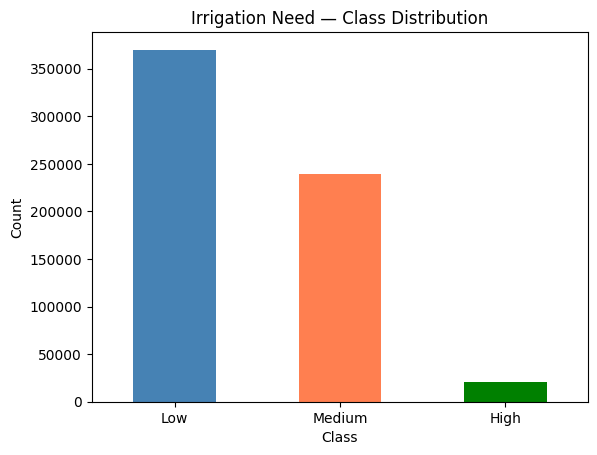

In [5]:
# How many Low / Medium / High are there?
print("Target distribution:")
print(train['Irrigation_Need'].value_counts())

# Plot it
train['Irrigation_Need'].value_counts().plot(
    kind='bar', 
    color=['steelblue', 'coral', 'green']
)
plt.title("Irrigation Need — Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

- The target classes are imbalanced. "Low" irrigation need is the most 
  common class, "Medium" is noticeably smaller, and "High" is the least 
  represented. This staircase pattern means a basic model might struggle 
  to correctly predict the "High" class since it has seen fewer examples 
  of it. This is why balanced accuracy is used as the evaluation metric 
  rather than regular accuracy.

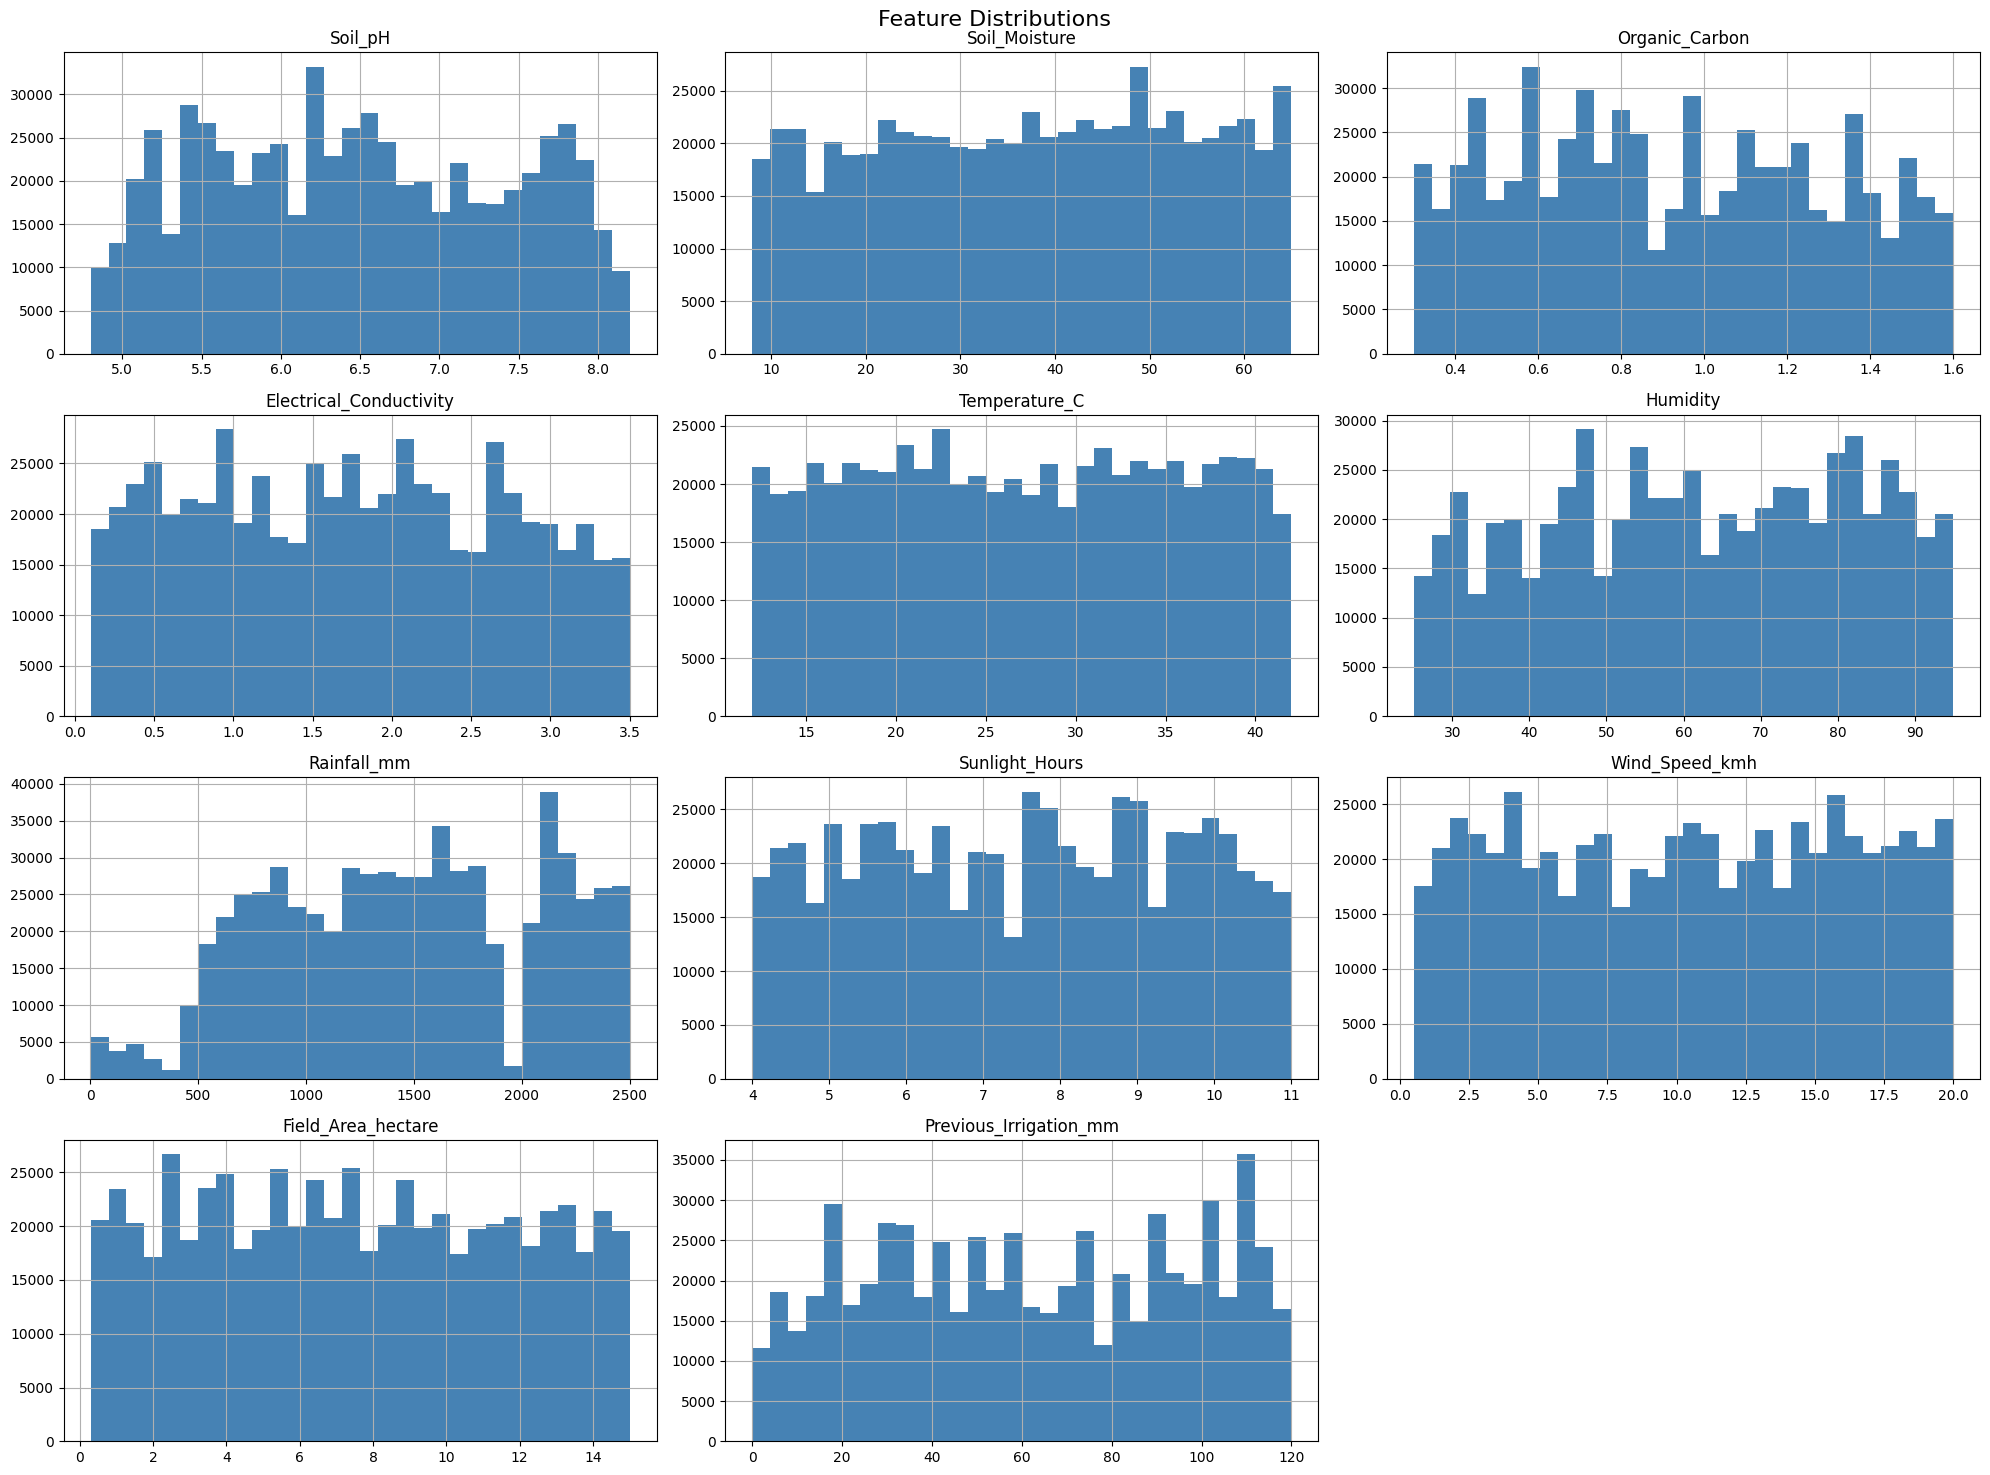

In [6]:
# Plot histograms for all numeric features
numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['id']]

train[numeric_cols].hist(figsize=(20, 15), bins=30, color='steelblue')
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

- Most features follow a roughly normal (bell-shaped) distribution, 
  suggesting the synthetic data generation did a good job mimicking 
  real-world patterns. The one exception is "rainfall_mm" which shows 
  a notably different distribution, likely because rainfall data in 
  real life is naturally skewed, but most readings are low with occasional 
  spikes of heavy rain. This feature may need special attention during 
  modeling.

Top features correlated with Irrigation Need:
Wind_Speed_kmh             0.128551
Temperature_C              0.099445
Rainfall_mm                0.027262
Electrical_Conductivity    0.021587
Field_Area_hectare         0.017761
Previous_Irrigation_mm     0.016354
Organic_Carbon             0.006026
Sunlight_Hours             0.004321
Humidity                  -0.018472
Soil_pH                   -0.019034
Name: target_encoded, dtype: float64


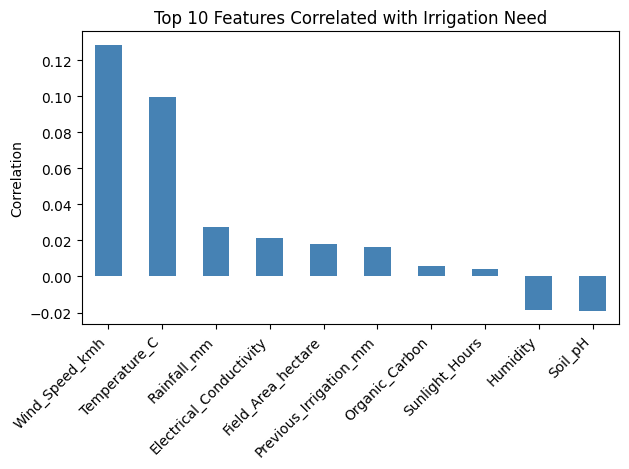

In [7]:
# Correlation of each feature with the target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
train['target_encoded'] = le.fit_transform(train['Irrigation_Need'])

corr = train[numeric_cols + ['target_encoded']].corr()['target_encoded']
corr = corr.drop('target_encoded').sort_values(ascending=False)

print("Top features correlated with Irrigation Need:")
print(corr.head(10))

# Plot it
corr.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Features Correlated with Irrigation Need")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- The features most strongly correlated with Irrigation 
  Need are Wind_Speed_kmh, Temperature_C, Rainfall_mm, 
  and Electrical_Conductivity. Wind speed being the 
  leading predictor makes practical sense, as higher winds 
  increase evaporation and dry out soil more quickly. 
  Temperature and rainfall follow logically for similar 
  reasons. That said, all correlation values are relatively 
  low, suggesting no single feature drives the prediction 
  on its own. The models will need to rely on patterns 
  across many features combined.

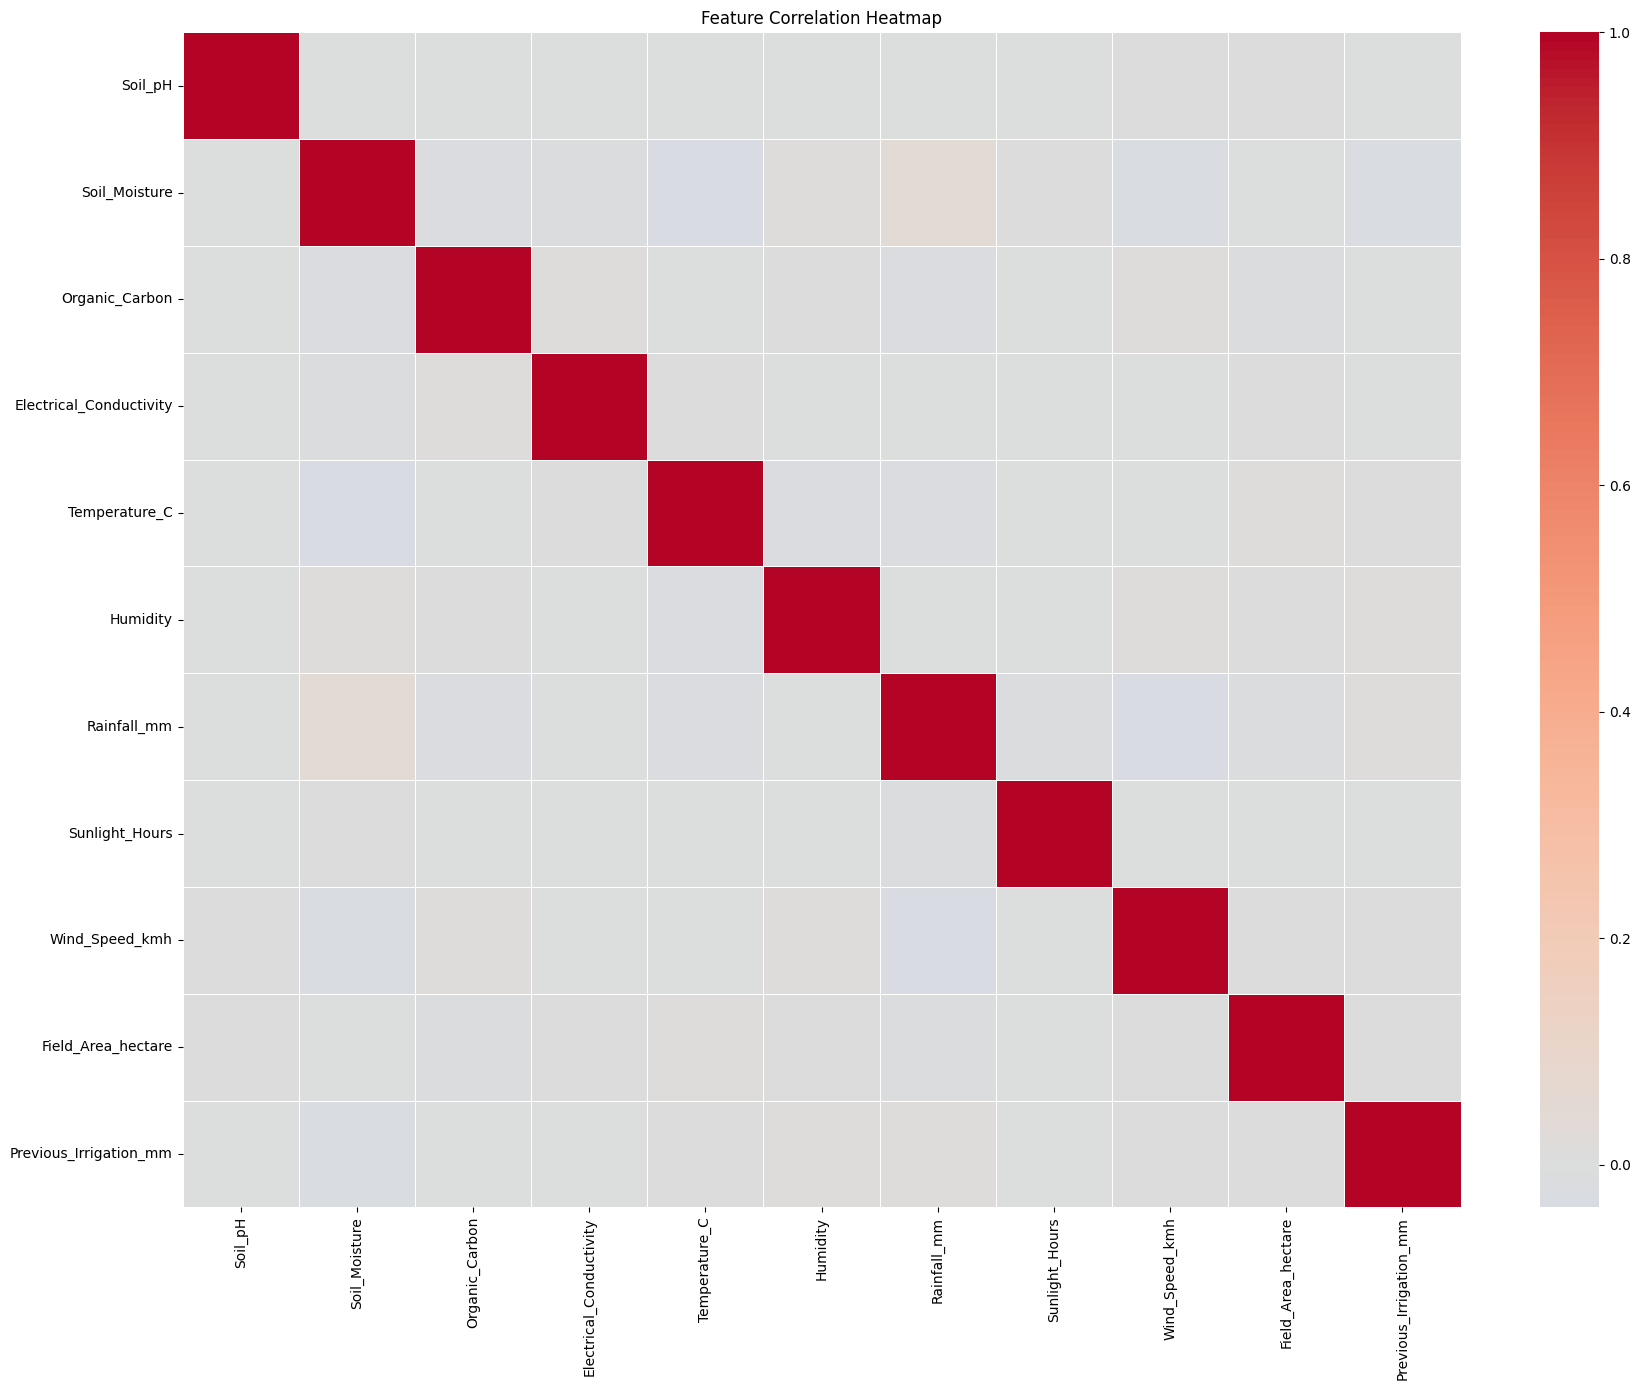

In [8]:
# Heatmap of all features
plt.figure(figsize=(18, 14))
sns.heatmap(
    train[numeric_cols].corr(), 
    cmap='coolwarm', 
    center=0,
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

- The correlation heatmap shows that most features are largely 
  independent from one another, with the off-diagonal cells 
  appearing light and neutral. The only mild exception is a 
  slight relationship between Soil_Moisture and Organic_Carbon, 
  which is expected in real-world agricultural data as soils 
  with more organic matter tend to retain moisture better. 
  Overall this suggests there is little redundancy among the 
  features, meaning most columns are likely contributing unique 
  information to the model.